# Level 2 — Task 4: Unveiling the Android App Market
## Google Play Store Analysis

### Project Overview

This project analyzes the Google Play Store ecosystem using data analysis and visualization techniques.

The analysis focuses on app categories, ratings, reviews, installs, app size, pricing, and user review sentiment to identify meaningful patterns and insights.

### Objectives

- Clean and preprocess Google Play Store data
- Analyze app categories and ratings
- Study the relationship between app size and installs
- Analyze free and paid applications
- Estimate revenue by category
- Perform sentiment analysis on user reviews
- Generate data-driven insights for app developers

### Tools & Technologies

Python, Pandas, NumPy, Matplotlib, Seaborn, TextBlob/VADER, Plotly

In [70]:
import pandas as pd

df = pd.read_csv("datasets/googleplaystore.csv")

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (10841, 13)

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

First 5 Rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [71]:
print("Data Types:")
print(df.dtypes)

Data Types:
App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


In [72]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [73]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 483


In [74]:
print("Duplicate App Names:", df["App"].duplicated().sum())

Duplicate App Names: 1181


In [75]:
print(df[df["App"].duplicated(keep=False)].sort_values("App").head(10))

                               App            Category  Rating Reviews  Size  \
1393         10 Best Foods for You  HEALTH_AND_FITNESS     4.0    2490  3.8M   
1407         10 Best Foods for You  HEALTH_AND_FITNESS     4.0    2490  3.8M   
2543    1800 Contacts - Lens Store             MEDICAL     4.7   23160   26M   
2322    1800 Contacts - Lens Store             MEDICAL     4.7   23160   26M   
2385    2017 EMRA Antibiotic Guide             MEDICAL     4.4      12  3.8M   
2256    2017 EMRA Antibiotic Guide             MEDICAL     4.4      12  3.8M   
1337  21-Day Meditation Experience  HEALTH_AND_FITNESS     4.4   11506   15M   
1434  21-Day Meditation Experience  HEALTH_AND_FITNESS     4.4   11506   15M   
3083       365Scores - Live Scores              SPORTS     4.6  666521   25M   
5415       365Scores - Live Scores              SPORTS     4.6  666246   25M   

         Installs  Type   Price Content Rating            Genres  \
1393     500,000+  Free       0   Everyone 10+  Hea

In [76]:
df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (10358, 13)


In [77]:
print("Missing Values After Removing Duplicates:")
print(df.isnull().sum())

Missing Values After Removing Duplicates:
App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [78]:
missing_rows = df[df.isnull().any(axis=1)]

print("Rows with missing values:", len(missing_rows))
display(missing_rows)

Rows with missing values: 1472


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2.7M,"5,000+",Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
123,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10824,Cardio-FR,MEDICAL,NaN,67,82M,"10,000+",Free,0,Everyone,Medical,"July 31, 2018",2.2.2,4.4 and up
10825,Naruto & Boruto FR,SOCIAL,NaN,7,7.7M,100+,Free,0,Teen,Social,"February 2, 2018",1.0,4.0 and up
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9.8M,"5,000+",Free,0,Everyone,Maps & Navigation,"June 13, 2018",2.0.148.0,4.0 and up
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up


In [79]:
missing_percent = df.isnull().mean() * 100

print("Missing Value Percentage:")
print(missing_percent.round(2))

Missing Value Percentage:
App                0.00
Category           0.00
Rating            14.14
Reviews            0.00
Size               0.00
Installs           0.00
Type               0.01
Price              0.00
Content Rating     0.01
Genres             0.00
Last Updated       0.00
Current Ver        0.08
Android Ver        0.03
dtype: float64


In [80]:
print("Rating Statistics:")
print(df["Rating"].describe())

Rating Statistics:
count    8893.000000
mean        4.189542
std         0.545452
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64


In [81]:
print("Invalid Ratings:")
display(df[df["Rating"] > 5])

Invalid Ratings:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [82]:
df = df.drop(index=10472)

print("New Dataset Shape:", df.shape)

New Dataset Shape: (10357, 13)


In [83]:
print("Rating Range:")
print("Minimum:", df["Rating"].min())
print("Maximum:", df["Rating"].max())

Rating Range:
Minimum: 1.0
Maximum: 5.0


In [84]:
print("Missing Ratings:", df["Rating"].isnull().sum())

Missing Ratings: 1465


In [85]:
print("Sample Review Counts:")
print(df["Reviews"].head(10))

Sample Review Counts:
0       159
1       967
2     87510
3    215644
4       967
5       167
6       178
7     36815
8     13791
9       121
Name: Reviews, dtype: str


In [86]:
df["Reviews"] = pd.to_numeric(df["Reviews"])

print("Reviews Data Type:", df["Reviews"].dtype)

Reviews Data Type: int64


In [87]:
print("Sample Install Values:")
print(df["Installs"].unique()[:20])

Sample Install Values:
<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+']
Length: 20, dtype: str


In [88]:
df["Installs"] = df["Installs"].str.replace(",", "").str.replace("+", "").astype(int)

print("Installs Data Type:", df["Installs"].dtype)

Installs Data Type: int64


In [89]:
print("Sample Size Values:")
print(df["Size"].unique()[:20])

Sample Size Values:
<StringArray>
[ '19M',  '14M', '8.7M',  '25M', '2.8M', '5.6M',  '29M',  '33M', '3.1M',
  '28M',  '12M',  '20M',  '21M',  '37M', '2.7M', '5.5M',  '17M',  '39M',
  '31M', '4.2M']
Length: 20, dtype: str


In [90]:
print("Varies with device:", (df["Size"] == "Varies with device").sum())

Varies with device: 1526


In [91]:
print(df["Size"].dropna()[~df["Size"].dropna().str.contains("M|k")].unique())

<StringArray>
['Varies with device']
Length: 1, dtype: str


In [92]:
df["Size"] = df["Size"].str.replace("M", "", regex=False)

df["Size"] = df["Size"].str.replace("k", "", regex=False)

df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

print("Size Data Type:", df["Size"].dtype)

Size Data Type: float64


In [93]:
size_original = pd.read_csv("datasets/googleplaystore.csv")["Size"]

print(size_original[size_original.str.contains("k", na=False)].head())

58     201k
209     23k
384     79k
450    118k
458    695k
Name: Size, dtype: str


In [94]:
size = size_original.copy()

size = size.replace("Varies with device", pd.NA)

size = size.apply(
    lambda x: float(x.replace("M", "")) if isinstance(x, str) and "M" in x
    else float(x.replace("k", "")) / 1000 if isinstance(x, str) and "k" in x
    else pd.NA
)

df["Size"] = size

print("Size Data Type:", df["Size"].dtype)

Size Data Type: object


In [95]:
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

print("Size Data Type:", df["Size"].dtype)

Size Data Type: float64


In [96]:
print(df["Size"].head(10))

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
5     5.6
6    19.0
7    29.0
8    33.0
9     3.1
Name: Size, dtype: float64


In [97]:
print("Sample Price Values:")
print(df["Price"].unique()[:20])

Sample Price Values:
<StringArray>
[     '0',  '$4.99',  '$3.99',  '$6.99',  '$1.49',  '$2.99',  '$7.99',
  '$5.99',  '$3.49',  '$1.99',  '$9.99',  '$7.49',  '$0.99',  '$9.00',
  '$5.49', '$10.00', '$24.99', '$11.99', '$79.99', '$16.99']
Length: 20, dtype: str


In [98]:
df["Price"] = df["Price"].str.replace("$", "", regex=False).astype(float)

print("Price Data Type:", df["Price"].dtype)

Price Data Type: float64


In [99]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
App                  0
Category             0
Rating            1465
Reviews              0
Size              1526
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64


In [100]:
print("Missing Type:")
display(df[df["Type"].isnull()])

Missing Type:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,NaN,0,NaN,0,NaN,0.0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [101]:
df.loc[df["Type"].isnull(), "Type"] = "Free"

print("Missing Type:", df["Type"].isnull().sum())

Missing Type: 0


In [102]:
print("Missing Current Ver:")
display(df[df["Current Ver"].isnull()])

Missing Current Ver:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2.700,5000,Free,0.00,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,0.011,1000000,Free,0.00,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8.700,500000,Free,0.00,Everyone,Tools,"May 10, 2017",NaN,4.0 and up
6803,BT Master,FAMILY,NaN,0,0.222,100,Free,0.00,Everyone,Education,"November 6, 2016",NaN,1.6 and up
7333,Dots puzzle,FAMILY,4.0,179,14.000,50000,Paid,0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up
7407,Calculate My IQ,FAMILY,NaN,44,7.200,10000,Free,0.00,Everyone,Entertainment,"April 3, 2017",NaN,2.3 and up
7730,UFO-CQ,TOOLS,NaN,1,0.237,10,Paid,0.99,Everyone,Tools,"July 4, 2016",NaN,2.0 and up
10342,La Fe de Jesus,BOOKS_AND_REFERENCE,NaN,8,0.658,1000,Free,0.00,Everyone,Books & Reference,"January 31, 2017",NaN,3.0 and up


In [103]:
df["Current Ver"] = df["Current Ver"].fillna("Unknown")

print("Missing Current Ver:", df["Current Ver"].isnull().sum())

Missing Current Ver: 0


In [104]:
print("Missing Android Ver:")
display(df[df["Android Ver"].isnull()])

Missing Android Ver:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11.0,1000,Paid,1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2.1,10000,Free,0.00,Everyone,Personalization,"March 27, 2018",1.1,NaN


In [105]:
df["Android Ver"] = df["Android Ver"].fillna("Unknown")

print("Missing Android Ver:", df["Android Ver"].isnull().sum())

Missing Android Ver: 0


In [106]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10357, 13)

Missing Values:
App                  0
Category             0
Rating            1465
Reviews              0
Size              1526
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64

Duplicate Rows: 0

Data Types:
App                   str
Category              str
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


In [107]:
category_counts = df["Category"].value_counts()

print("Apps by Category:")
print(category_counts)

Apps by Category:
Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64


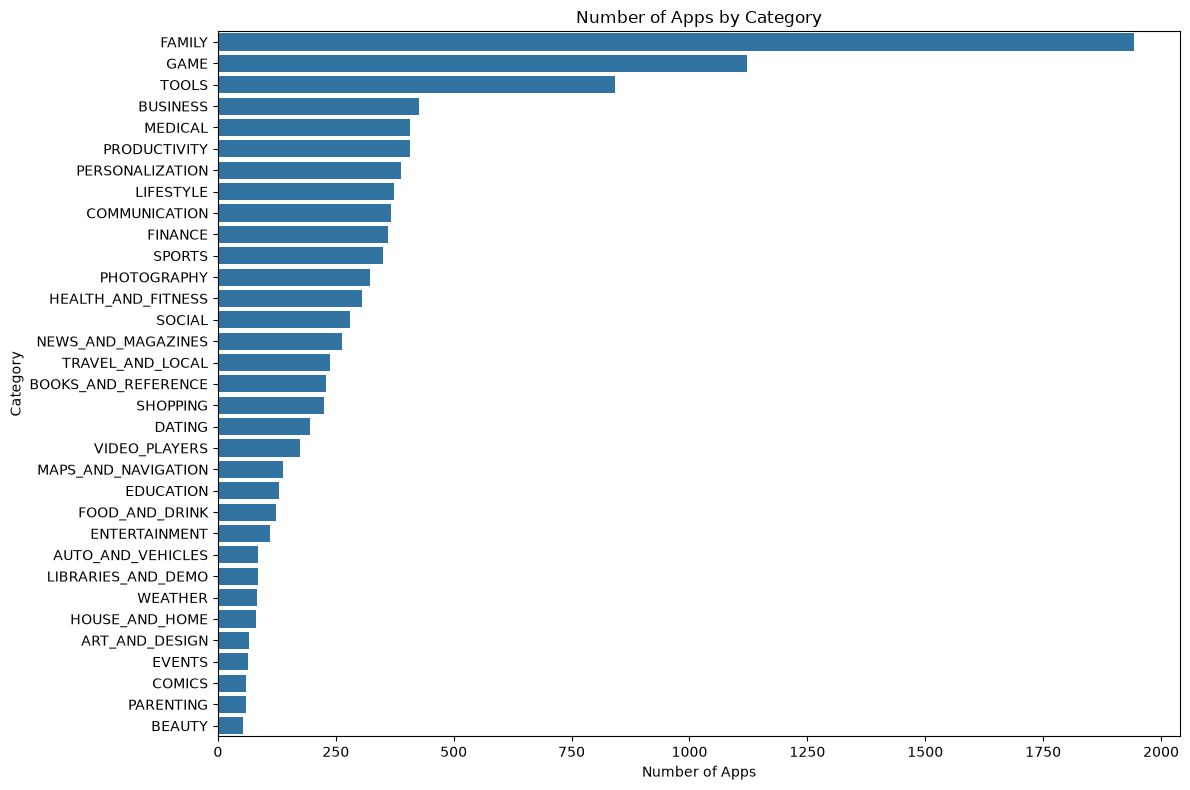

In [108]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig("outputs/category_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [109]:
category_percentage = (category_counts / len(df)) * 100

print("Category Percentage:")
print(category_percentage.round(2))

Category Percentage:
Category
FAMILY                 18.76
GAME                   10.82
TOOLS                   8.14
BUSINESS                4.12
MEDICAL                 3.94
PRODUCTIVITY            3.93
PERSONALIZATION         3.75
LIFESTYLE               3.60
COMMUNICATION           3.53
FINANCE                 3.48
SPORTS                  3.39
PHOTOGRAPHY             3.11
HEALTH_AND_FITNESS      2.95
SOCIAL                  2.70
NEWS_AND_MAGAZINES      2.55
TRAVEL_AND_LOCAL        2.29
BOOKS_AND_REFERENCE     2.22
SHOPPING                2.16
DATING                  1.89
VIDEO_PLAYERS           1.69
MAPS_AND_NAVIGATION     1.32
EDUCATION               1.26
FOOD_AND_DRINK          1.20
ENTERTAINMENT           1.07
AUTO_AND_VEHICLES       0.82
LIBRARIES_AND_DEMO      0.82
WEATHER                 0.79
HOUSE_AND_HOME          0.77
ART_AND_DESIGN          0.63
EVENTS                  0.62
COMICS                  0.58
PARENTING               0.58
BEAUTY                  0.51
Name: count, 

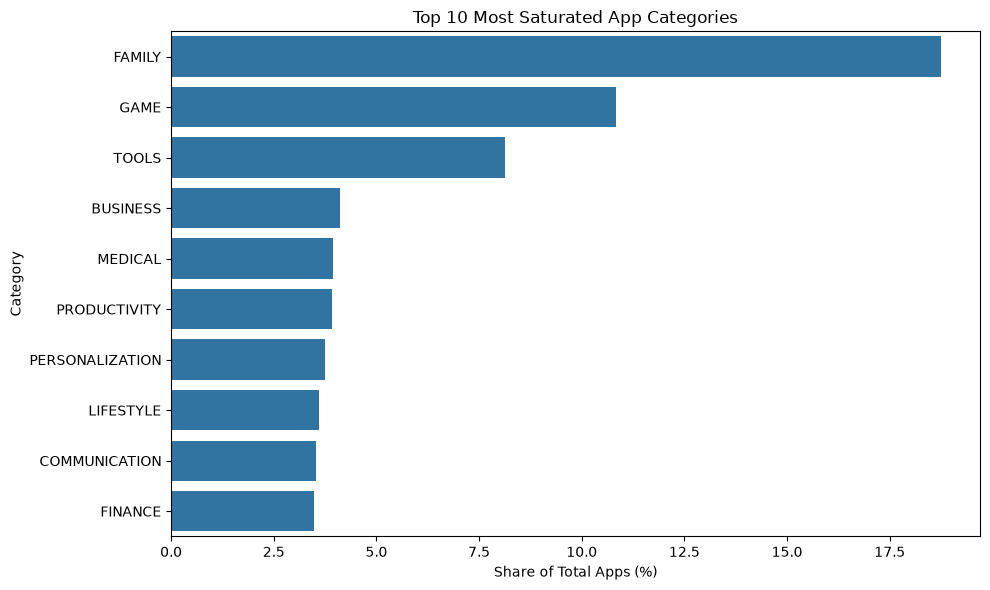

In [110]:
top_10_categories = category_percentage.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_categories.values,
    y=top_10_categories.index
)

plt.title("Top 10 Most Saturated App Categories")
plt.xlabel("Share of Total Apps (%)")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(
    "outputs/top_10_category_saturation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

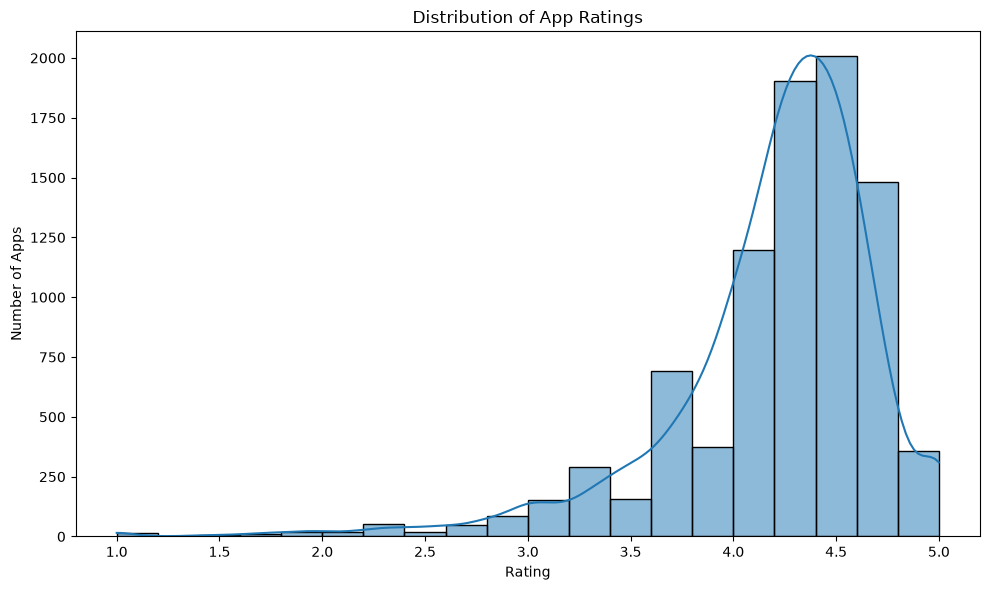

In [111]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()

plt.savefig(
    "outputs/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
avg_rating_category = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

print("Average Rating by Category:")
print(avg_rating_category.round(2))

Average Rating by Category:
Category
EVENTS                 4.44
EDUCATION              4.38
ART_AND_DESIGN         4.36
BOOKS_AND_REFERENCE    4.35
PERSONALIZATION        4.33
PARENTING              4.30
GAME                   4.28
BEAUTY                 4.28
HEALTH_AND_FITNESS     4.26
SOCIAL                 4.25
SHOPPING               4.25
WEATHER                4.24
SPORTS                 4.23
PRODUCTIVITY           4.20
FAMILY                 4.19
AUTO_AND_VEHICLES      4.19
PHOTOGRAPHY            4.18
MEDICAL                4.18
LIBRARIES_AND_DEMO     4.18
HOUSE_AND_HOME         4.16
FOOD_AND_DRINK         4.16
COMICS                 4.16
COMMUNICATION          4.15
ENTERTAINMENT          4.14
NEWS_AND_MAGAZINES     4.13
FINANCE                4.13
BUSINESS               4.10
LIFESTYLE              4.10
TRAVEL_AND_LOCAL       4.09
VIDEO_PLAYERS          4.06
MAPS_AND_NAVIGATION    4.05
TOOLS                  4.05
DATING                 3.97
Name: Rating, dtype: float64


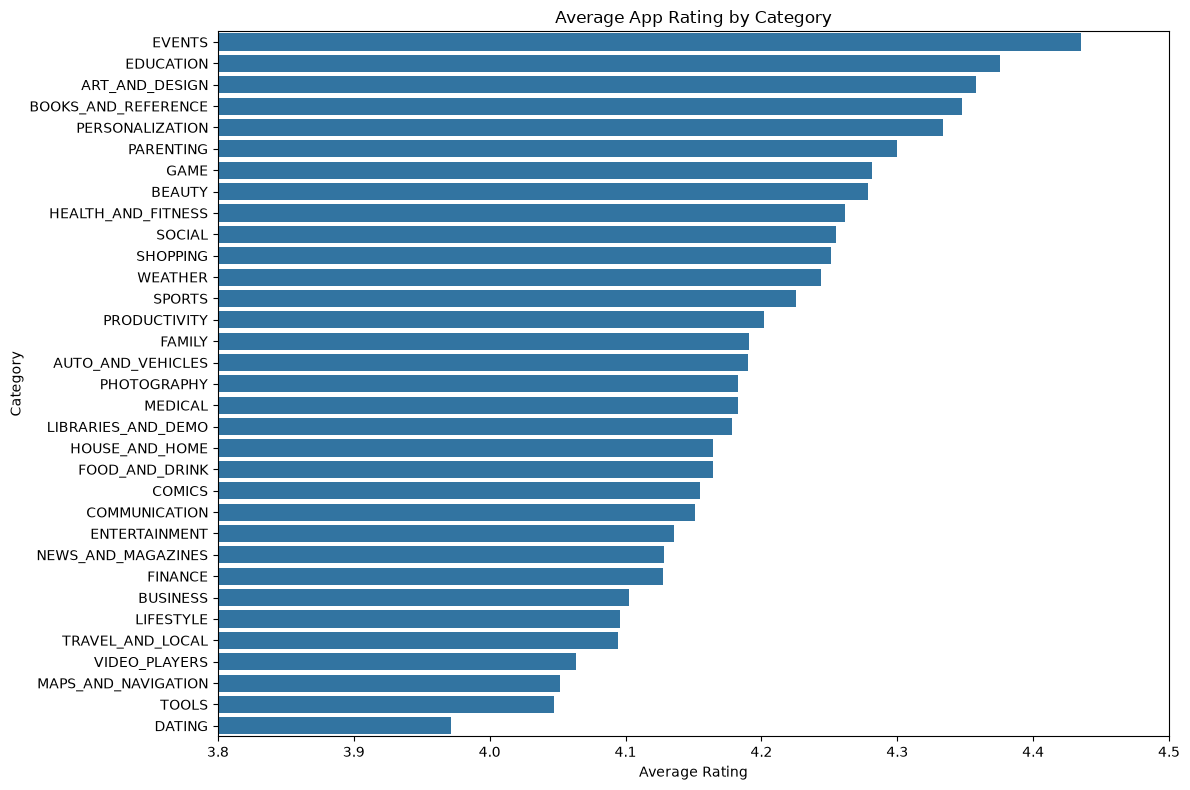

In [113]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(3.8, 4.5)
plt.tight_layout()

plt.savefig(
    "outputs/average_rating_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
size_install_data = df[["Size", "Installs"]].dropna()

correlation = size_install_data["Size"].corr(
    size_install_data["Installs"]
)

print("Size vs Installs Correlation:", round(correlation, 3))

Size vs Installs Correlation: 0.169


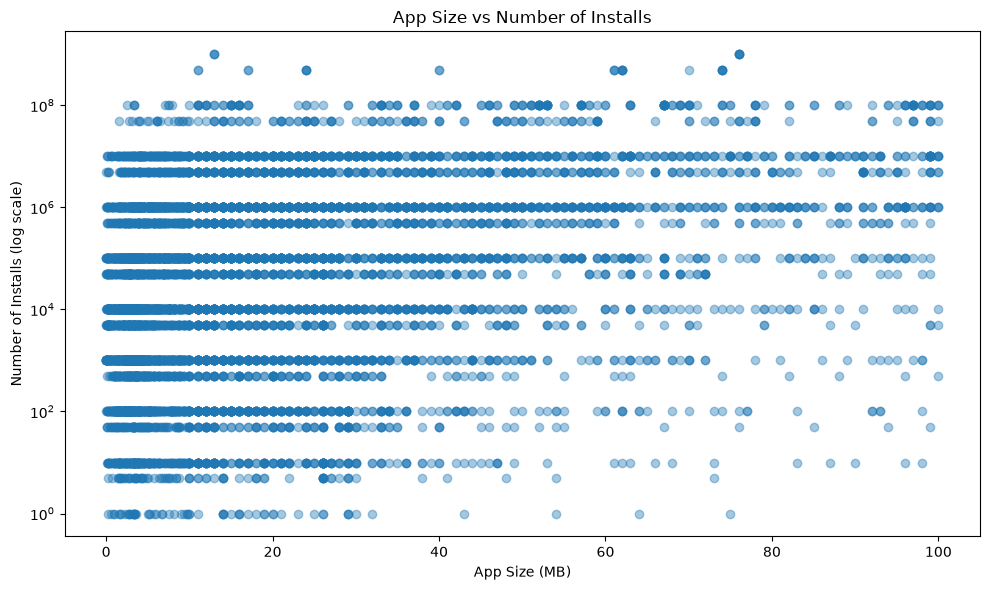

In [115]:
plt.figure(figsize=(10, 6))

plt.scatter(
    size_install_data["Size"],
    size_install_data["Installs"],
    alpha=0.4
)

plt.yscale("log")

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs (log scale)")
plt.tight_layout()

plt.savefig(
    "outputs/size_vs_installs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [116]:
app_type_counts = df["Type"].value_counts()

print("Free vs Paid Apps:")
print(app_type_counts)

Free vs Paid Apps:
Type
Free    9592
Paid     765
Name: count, dtype: int64


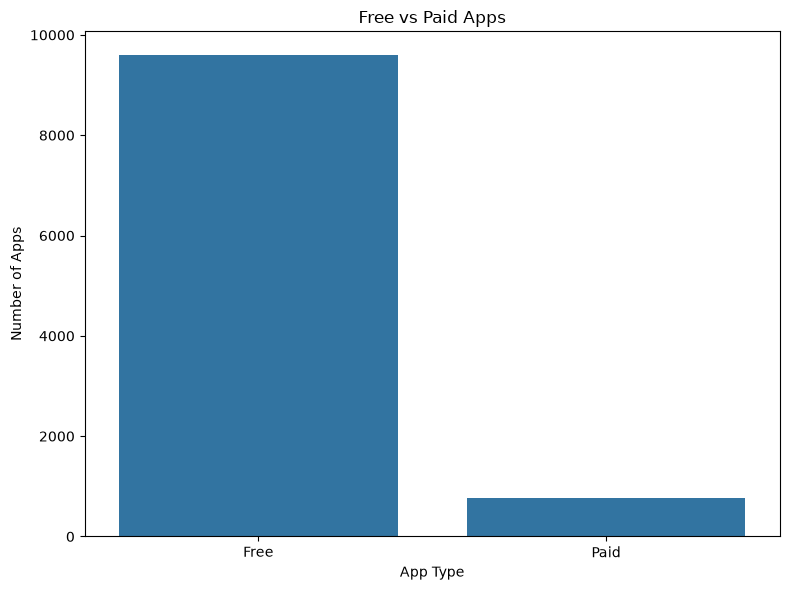

In [117]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=app_type_counts.index,
    y=app_type_counts.values
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.tight_layout()

plt.savefig(
    "outputs/free_vs_paid_apps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
paid_apps = df[df["Price"] > 0]

print("Number of Paid Apps:", len(paid_apps))
print("\nPrice Statistics:")
print(paid_apps["Price"].describe())

Number of Paid Apps: 765

Price Statistics:
count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


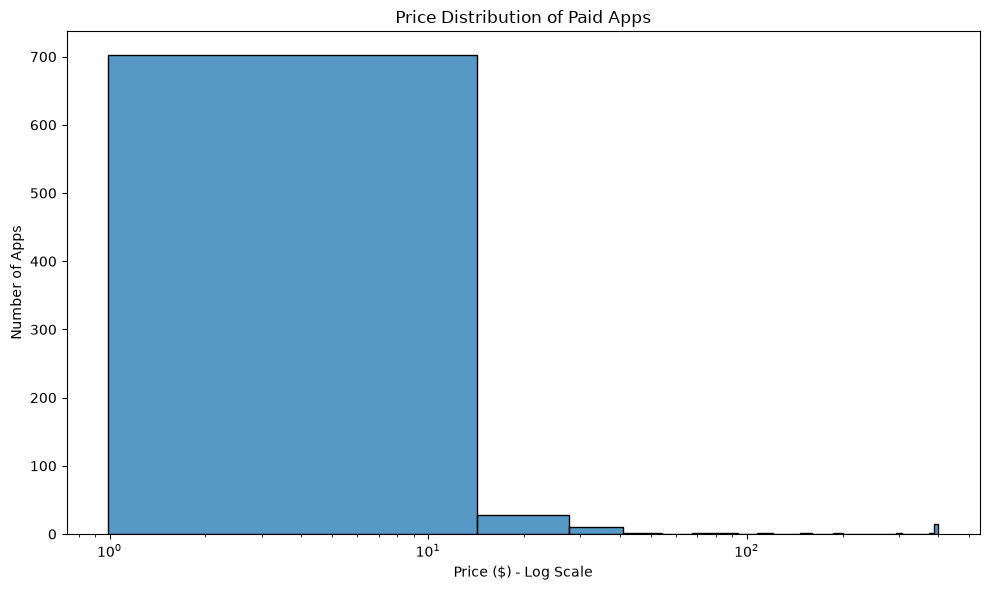

In [119]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30
)

plt.xscale("log")

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($) - Log Scale")
plt.ylabel("Number of Apps")
plt.tight_layout()

plt.savefig(
    "outputs/paid_app_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
paid_apps = df[df["Price"] > 0].copy()

paid_apps["Estimated Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

revenue_by_category = (
    paid_apps.groupby("Category")["Estimated Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
print(revenue_by_category.round(2))

Estimated Revenue by Category:
Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6

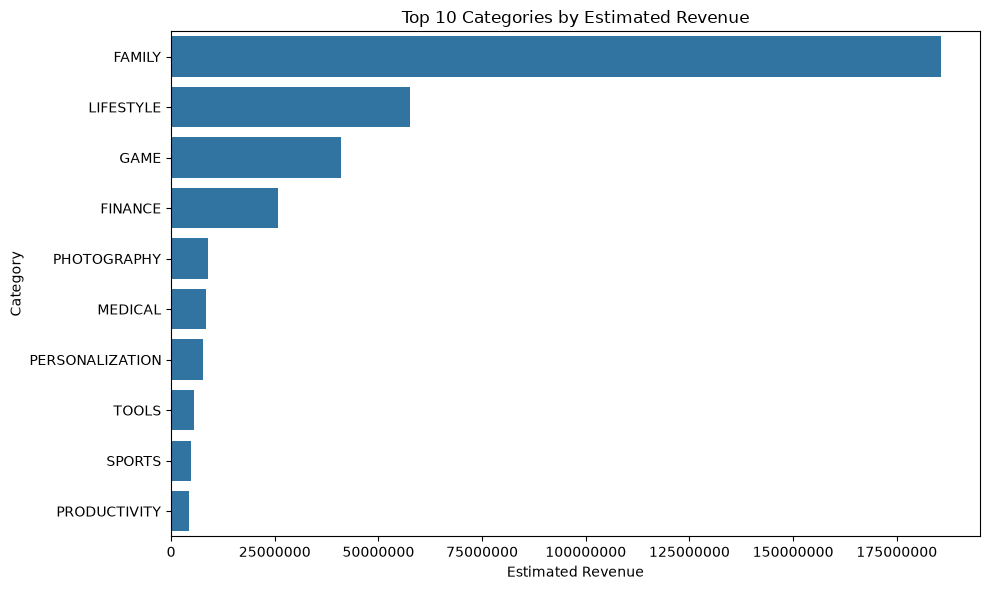

In [121]:
top_10_revenue = revenue_by_category.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_revenue.values,
    y=top_10_revenue.index
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Category")
plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()

plt.savefig(
    "outputs/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [122]:
reviews_df = pd.read_csv("datasets/googleplaystore_user_reviews.csv")

print("Reviews Dataset Shape:", reviews_df.shape)

print("\nColumns:")
print(reviews_df.columns.tolist())

display(reviews_df.head())

Reviews Dataset Shape: (64295, 5)

Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [123]:
print("Missing Values:")
print(reviews_df.isnull().sum())

Missing Values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [124]:
reviews_clean = reviews_df.dropna(subset=["Translated_Review"]).copy()

print("Original Reviews:", len(reviews_df))
print("Reviews After Cleaning:", len(reviews_clean))

Original Reviews: 64295
Reviews After Cleaning: 37427


In [125]:
reviews_clean = reviews_clean.dropna(subset=["Sentiment"]).copy()

print("Clean Reviews Shape:", reviews_clean.shape)

print("\nMissing Values:")
print(reviews_clean.isnull().sum())

Clean Reviews Shape: (37427, 5)

Missing Values:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


In [126]:
sentiment_counts = reviews_clean["Sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


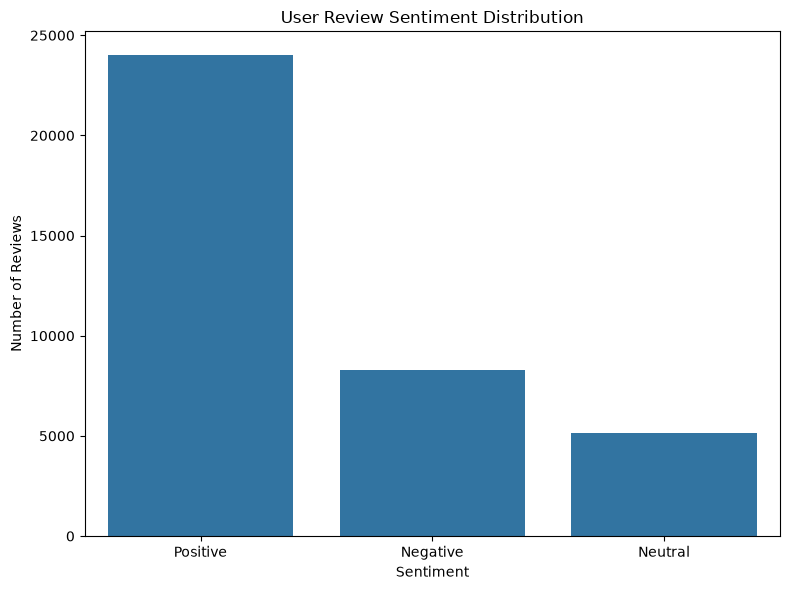

In [127]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.savefig("outputs/sentiment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [128]:
reviews_category = reviews_clean.merge(
    df[["App", "Category"]],
    on="App",
    how="left"
)

print("Reviews with Category:", reviews_category.shape)

print("\nMissing Categories:")
print(reviews_category["Category"].isnull().sum())

Reviews with Category: (60661, 6)

Missing Categories:
1498


In [129]:
app_category_counts = df.groupby("App")["Category"].nunique()

print("Apps with Multiple Categories:")
print((app_category_counts > 1).sum())

Apps with Multiple Categories:
85


In [130]:
app_category_map = (
    df.groupby("App")["Category"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

print("Unique App-Category Mapping:", app_category_map.shape)

print("\nDuplicate Apps in Mapping:")
print(app_category_map["App"].duplicated().sum())

Unique App-Category Mapping: (9659, 2)

Duplicate Apps in Mapping:
0


In [131]:
reviews_category = reviews_clean.merge(
    app_category_map,
    on="App",
    how="left"
)

print("Reviews with Category:", reviews_category.shape)

print("\nMissing Categories:")
print(reviews_category["Category"].isnull().sum())

Reviews with Category: (37427, 6)

Missing Categories:
1498


In [132]:
unmatched_apps = reviews_category[
    reviews_category["Category"].isnull()
]["App"].unique()

print("Unmatched Apps:", len(unmatched_apps))

print("\nSample Unmatched Apps:")
print(unmatched_apps[:20])

Unmatched Apps: 49

Sample Unmatched Apps:
<StringArray>
[                  '104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室',
 '591房屋交易-租屋、中古屋、新建案、實價登錄、別墅透天、公寓套房、捷運、買房賣房行情、房價房貸查詢',
                                         '591房屋交易-香港',
                                                'ANA',
                        'AirBrush: Easy Photo Editor',
                                  'Apple Daily 蘋果動新聞',
                        'Aprender inglés con Wlingua',
                                 'BaBe - Baca Berita',
                'BaBe Lite - Baca Berita Hemat Kuota',
                           'BaBe+ - Berita Indonesia',
 'Baca- Berita Terbaru, Informasi, Gosip dan Politik',
                           'Bagan - Myanmar Keyboard',
                                         'Banco Itaú',
                                    'Banco do Brasil',
                                     'Bancomer móvil',
                     'Bangla Newspaper – Prothom Alo',
                                   'Banque Populaire',
        

In [133]:
reviews_category_clean = reviews_category.dropna(
    subset=["Category"]
).copy()

print("Reviews for Category Analysis:", len(reviews_category_clean))

print("\nMissing Categories:")
print(reviews_category_clean["Category"].isnull().sum())

Reviews for Category Analysis: 35929

Missing Categories:
0


In [134]:
sentiment_by_category = pd.crosstab(
    reviews_category_clean["Category"],
    reviews_category_clean["Sentiment"],
    normalize="index"
) * 100

print("Sentiment by Category (%):")
display(sentiment_by_category.round(2))

Sentiment by Category (%):


Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.97,16.23,67.80
AUTO_AND_VEHICLES,5.88,12.46,81.66
BEAUTY,19.23,26.04,54.73
BOOKS_AND_REFERENCE,14.59,16.59,68.82
BUSINESS,15.62,23.84,60.54
COMICS,2.22,11.11,86.67
COMMUNICATION,20.21,17.19,62.60
DATING,21.05,16.68,62.27
EDUCATION,11.20,13.84,74.96


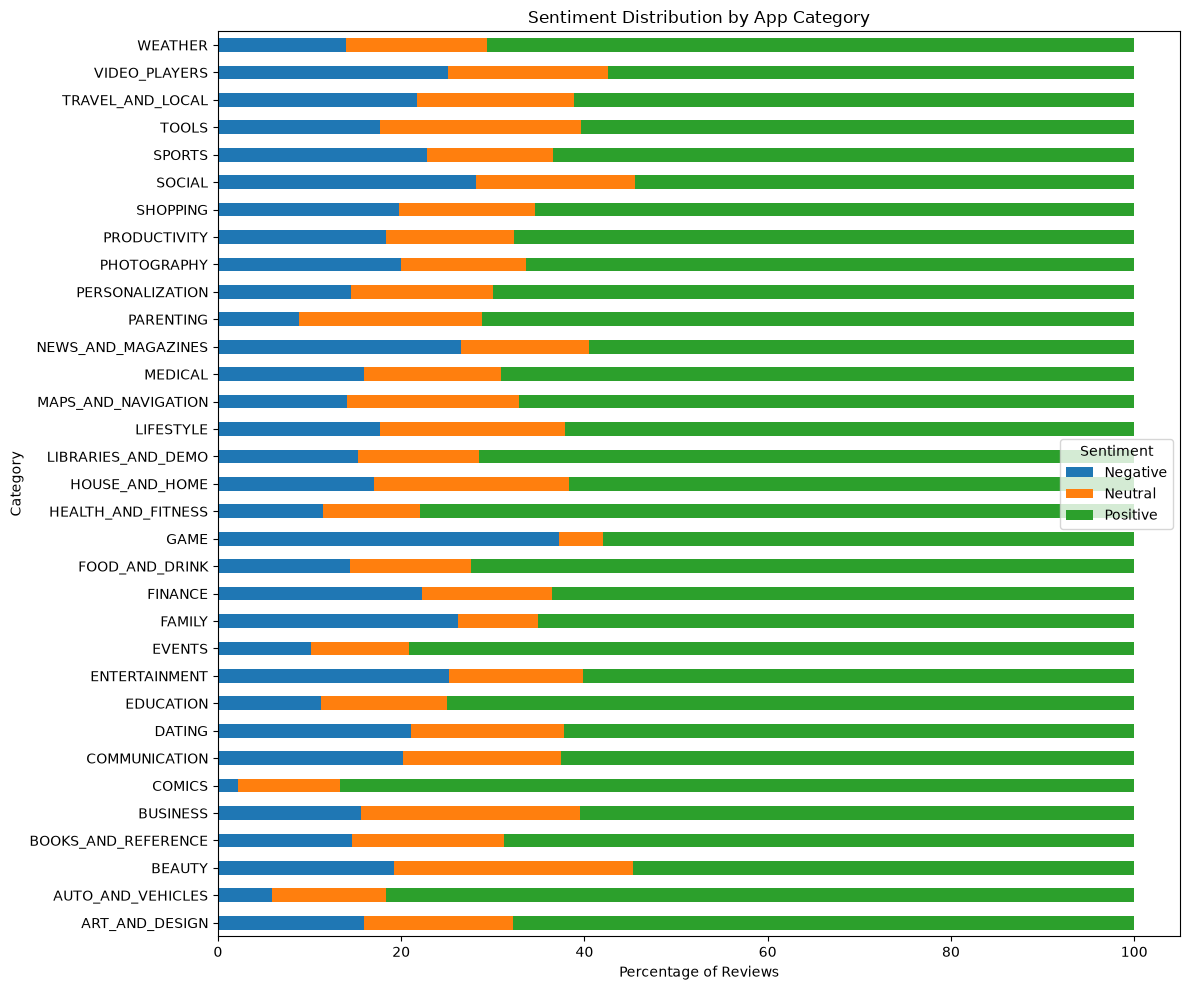

In [135]:
sentiment_by_category.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 10)
)

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Category")
plt.legend(title="Sentiment")
plt.tight_layout()

plt.savefig(
    "outputs/sentiment_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [136]:
import plotly.express as px

plotly_rating = avg_rating_category.reset_index()

fig = px.bar(
    plotly_rating,
    x="Rating",
    y="Category",
    orientation="h",
    title="Interactive Average Rating by App Category",
    labels={
        "Rating": "Average Rating",
        "Category": "App Category"
    }
)

fig.show()
fig.write_html("outputs/interactive_average_rating.html")

## Key Insights for App Developers

### 1. Focus on user experience in highly competitive categories
The FAMILY category is the most saturated category, accounting for approximately 18.76% of all apps, followed by GAME (10.82%) and TOOLS (8.14%). Developers entering highly saturated categories should focus on differentiation, usability, and unique features.

### 2. Negative feedback is particularly high in Games and Social apps
GAME has the highest negative sentiment share at 37.20%, while SOCIAL has 28.21% negative reviews. This indicates a strong opportunity for developers in these categories to improve app performance, user experience, and address recurring user complaints.

### 3. Free apps dominate the Google Play Store
Approximately 92.62% of the analyzed apps are free, while only 7.38% are paid. Among paid apps, the median price is $2.99, while the mean price is higher at $13.96 due to a small number of expensive apps. Developers should carefully evaluate pricing and consider a free or freemium model when entering competitive markets.

### 4. App size alone does not strongly drive installs
The correlation between app size and installs is approximately 0.169, indicating a weak positive relationship. Developers should therefore prioritize functionality, user experience, and value rather than assuming a larger app will attract more downloads.